Drift estimate (mu_hat): 0.2723
Classical annualized volatility: 0.2815
Parkinson volatility: 0.2239
Garman Klass volatility: 0.2247

Fetching SPX and VIX market data
Last bus day: 2025-03-05, S0: 5842.63, F0: 5852.24, Market VIX: 21.93

Option chain VIX estimation
Selected expiry date: 2026-02-25
Calculated VIX: 59.21 vs CBOE VIX: 21.93

Statistical Analysis & Regressions


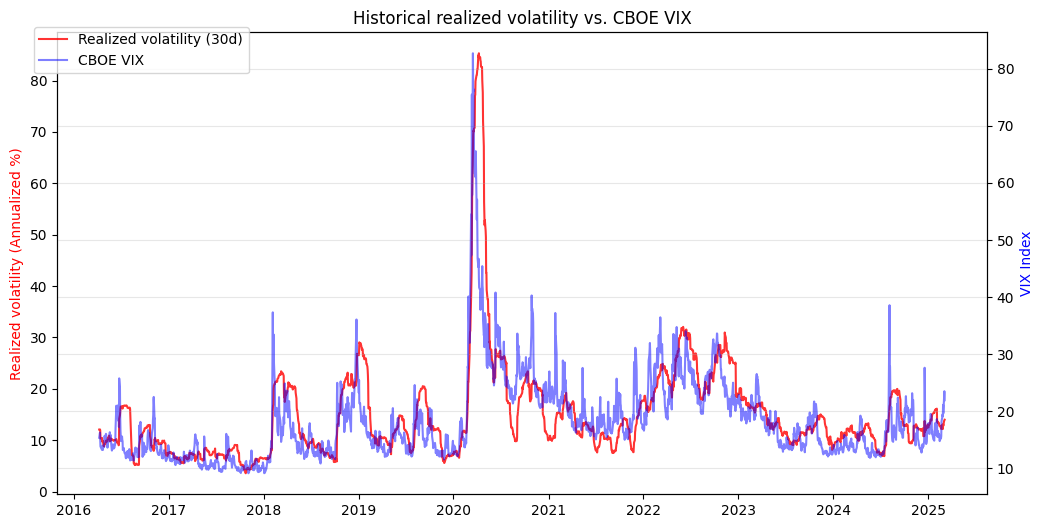

Correlation (Realized Vol vs VIX Level): 0.8079 (p-value: 0.0000e+00)

Regression 1: SPX Returns - VIX Variations
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      3.572      0.000       0.000       0.001
VIX_Diff      -0.0045   7.92e-05    -57.092      0.000      -0.005      -0.004

Regression 2: SPX Returns - Realized Volatility Variations
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      2.245      0.025    6.76e-05       0.001
RV_Diff       -0.0016      0.000     -5.683      0.000      -0.002      -0.001


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import math
from pandas_datareader import data as pdr
from scipy.stats import pearsonr
import statsmodels.api as sm
from skfolio.datasets import load_sp500_dataset, load_sp500_implied_vol_dataset
from skfolio.preprocessing import prices_to_returns
from yahooquery import Ticker


def download_prices_stooq(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    candidates = [ticker, ticker.upper(), f"{ticker.upper()}.US"]
    last_err = None
    for t in candidates:
        try:
            df = pdr.DataReader(t, "stooq", start, end)
            if df is not None and not df.empty:
                df = df.sort_index()
                df.index = pd.to_datetime(df.index)
                return df
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Download failed. Last error: {last_err}")

ticker = "AAPL"
start_date = "2010-01-01"
end_date = dt.date.today().strftime("%Y-%m-%d")

data = download_prices_stooq(ticker, start_date, end_date)
close = data["Close"].astype(float)
high = data["High"].astype(float)
low = data["Low"].astype(float)
open_price = data["Open"].astype(float)

returns = close.pct_change().dropna()
log_returns = np.log(close / close.shift(1)).dropna()

N = len(returns)
dt_daily = 1/252
T_total = N * dt_daily
mu_hat = (1/N) * np.sum(returns / dt_daily)
sigma2_hat = (1/(N-1)) * np.sum((returns**2)/dt_daily) - (T_total/(N-1)) * mu_hat**2
sigma_hat = np.sqrt(sigma2_hat)

parkinson_var = (1/(4*np.log(2))) * np.mean((np.log(high/low))**2) * 252
parkinson_vol = np.sqrt(parkinson_var)

term1 = 0.5 * (np.log(high/low))**2
term2 = (2*np.log(2)-1) * (np.log(close/open_price))**2
gk_var = np.mean(term1 - term2) * 252
gk_vol = np.sqrt(gk_var)

print(f"Drift estimate (mu_hat): {mu_hat:.4f}")
print(f"Classical annualized volatility: {sigma_hat:.4f}")
print(f"Parkinson volatility: {parkinson_vol:.4f}")
print(f"Garman Klass volatility: {gk_vol:.4f}\n")

prices = load_sp500_dataset()
implied_vol = load_sp500_implied_vol_dataset()
returns_sp = prices_to_returns(prices).loc["2010":]
realized_sp = returns_sp.rolling(30).std() * np.sqrt(252)


print("Fetching SPX and VIX market data")
def fetch_spx_close(start_date, end_date):
    start, end = pd.to_datetime(start_date), pd.to_datetime(end_date)
    try:
        df = pdr.DataReader("SP500", "fred", start, end)
        return df.rename(columns={"SP500": "Close"}).dropna()[["Close"]]
    except: pass
    df = pdr.DataReader("^SPX", "stooq", start, end).sort_index()
    return df[["Close"]].dropna()

def fetch_vix_close(start_date, end_date):
    start, end = pd.to_datetime(start_date), pd.to_datetime(end_date)
    try:
        df = pdr.DataReader("VIXCLS", "fred", start, end)
        return df.rename(columns={"VIXCLS": "Close"}).dropna()[["Close"]]
    except: pass
    for sym in ["VI.F", "vi.f", "^VIX", "^vix"]:
        try:
            df = pdr.DataReader(sym, "stooq", start, end).sort_index()
            if not df.empty and "Close" in df.columns:
                return df[["Close"]].dropna()
        except: continue
    raise ValueError("No VIX data found.")

today = pd.to_datetime("2025-03-05")
spx_start_date = today - dt.timedelta(days=365)

spx_data = fetch_spx_close(spx_start_date, today)
lastBusDay = spx_data.index[-1]
S0 = float(spx_data["Close"].iloc[-1])

vix_data_short = fetch_vix_close(lastBusDay, lastBusDay + dt.timedelta(days=30))
vix_market = float(vix_data_short["Close"].iloc[0])

T = 30/365.0
r = 0.02
F0 = S0 * math.exp(r * T)
print(f"Last bus day: {lastBusDay.date()}, S0: {S0:.2f}, F0: {F0:.2f}, Market VIX: {vix_market:.2f}\n")


def compute_vix_from_chain(options_df, F, r, tau):
    calls = options_df[options_df["type"]=="call"].sort_values("strike")
    puts = options_df[options_df["type"]=="put"].sort_values("strike")

    puts_otm = puts[puts["strike"] < F]
    calls_otm = calls[calls["strike"] > F]

    put_strikes = puts_otm["strike"].values
    put_prices = puts_otm["price"].values

    call_strikes = calls_otm["strike"].values
    call_prices = calls_otm["price"].values

    vix_sum = 0
    extended_put_strikes = np.append(put_strikes, F)

    for i in range(len(put_strikes)):
        K_i = extended_put_strikes[i]
        K_next = extended_put_strikes[i+1]
        P = put_prices[i]
        vix_sum += P * ((1.0 / K_i) - (1.0 / K_next))


    extended_call_strikes = np.insert(call_strikes, 0, F)

    for i in range(len(call_strikes)):
        K_prev = extended_call_strikes[i]
        K_i = extended_call_strikes[i+1]
        C = call_prices[i]
        vix_sum += C * ((1.0 / K_prev) - (1.0 / K_i))

    vix2 = (2 * np.exp(r * tau) / tau) * vix_sum

    return np.sqrt(vix2) * 100
print("Option chain VIX estimation")
oc = Ticker("^SPX").option_chain

if oc is not None and not oc.empty:
    options_df = oc.reset_index()

    expirations = pd.to_datetime(options_df['expiration'].unique())
    target_date = today + dt.timedelta(days=30)
    best_expiry = expirations[np.argmin(np.abs(expirations - target_date))].strftime('%Y-%m-%d')
    print(f"Selected expiry date: {best_expiry}")

    options_30d = options_df[options_df['expiration'] == best_expiry].copy()
    options_30d['price'] = (options_30d['bid'] + options_30d['ask']) / 2.0
    options_30d['type'] = options_30d['optionType'].str[:-1]

    estimated_vix = compute_vix_from_chain(options_30d, F0, r, T)
    print(f"Calculated VIX: {estimated_vix:.2f} vs CBOE VIX: {vix_market:.2f}\n")
else:
    print("No option chain available from yahooquery today.\n")

print("Statistical Analysis & Regressions")
spx_hist = fetch_spx_close("2015-01-01", today)
vix_hist = fetch_vix_close("2015-01-01", today)
df_stats = pd.DataFrame()
df_stats['SPX_Return'] = spx_hist['Close'].pct_change()
df_stats['VIX'] = vix_hist['Close']

def rolling_variance(ret_array):
    N_win = len(ret_array)
    mu = (1/N_win) * np.sum(ret_array / dt_daily)
    return (1/(N_win-1)) * np.sum((ret_array**2)/dt_daily) - ((N_win*dt_daily)/(N_win-1)) * mu**2

df_stats['Realized_Var'] = df_stats['SPX_Return'].rolling(30).apply(rolling_variance, raw=True)
df_stats['Realized_Vol'] = np.sqrt(df_stats['Realized_Var']) * 100
df_stats = df_stats.dropna()

fig, ax1 = plt.subplots(figsize=(12,6))
ax1.plot(df_stats.index, df_stats['Realized_Vol'], color='red', label='Realized volatility (30d)', alpha=0.8)
ax1.set_ylabel('Realized volatility (Annualized %)', color='red')
ax1.set_title('Historical realized volatility vs. CBOE VIX')

ax2 = ax1.twinx()
ax2.plot(df_stats.index, df_stats['VIX'], color='blue', label='CBOE VIX', alpha=0.5)
ax2.set_ylabel('VIX Index', color='blue')
fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))
plt.grid(True, alpha=0.3)
plt.show()
corr, p = pearsonr(df_stats['Realized_Vol'], df_stats['VIX'])
print(f"Correlation (Realized Vol vs VIX Level): {corr:.4f} (p-value: {p:.4e})\n")

df_stats['VIX_Diff'] = df_stats['VIX'].diff()
df_stats['RV_Diff'] = df_stats['Realized_Vol'].diff()
df_stats = df_stats.dropna()

print("Regression 1: SPX Returns - VIX Variations")
X_vix = sm.add_constant(df_stats['VIX_Diff'])
model_vix = sm.OLS(df_stats['SPX_Return'], X_vix).fit()
print(model_vix.summary().tables[1])

print("\nRegression 2: SPX Returns - Realized Volatility Variations")
X_rv = sm.add_constant(df_stats['RV_Diff'])
model_rv = sm.OLS(df_stats['SPX_Return'], X_rv).fit()
print(model_rv.summary().tables[1])